**Overview**

This visualization provides a clear breakdown of the most sought-after skills for Data Analysts based on job posting data from 2023. The analysis highlights the technical proficiency required in today's job market, focusing on programming languages, database management, and data visualization tools.

*Methodology*
The chart was generated using the matplotlib and pandas libraries in Python.

Important Note: The underlying data for this graph was sourced by exporting the output of Query 2 as a JSON file. This ensures that the visualization directly reflects the results of the SQL analysis.

*Process summery*
[x] Download JSON data from SQL output

[x] Create bar chart using Matplotlib

[x] Format axis labels and title

**Query 2:**
```sql
WITH top_jobs AS (
    SELECT
        job_id,
        job_title,
        salary_year_avg,
        name AS company_name
    FROM
        job_postings_fact
    LEFT JOIN company_dim ON job_postings_fact.company_id = company_dim.company_id
    WHERE
        job_title_short = 'Data Analyst' AND
        job_location = 'Anywhere' AND
        salary_year_avg IS NOT NULL
    ORDER BY
        salary_year_avg DESC
    LIMIT 10
)

SELECT top_jobs.* , skills
FROM top_jobs
INNER JOIN skills_job_dim on top_jobs.job_id = skills_job_dim.job_id
INNER JOIN skills_dim on skills_job_dim.skill_id = skills_dim.skill_id

```



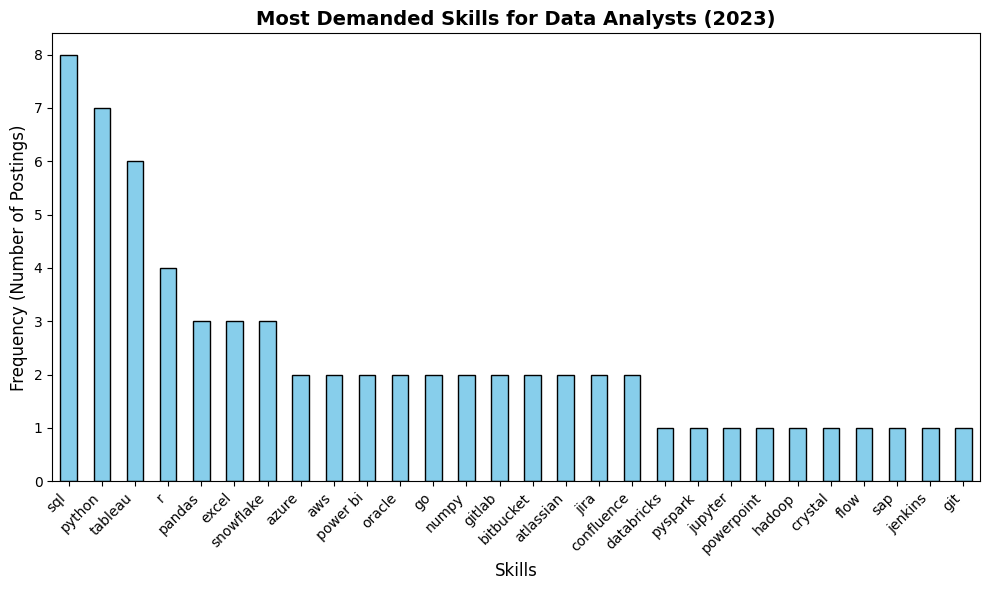

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# The data you provided
data = [
  {"job_id": 552322, "job_title": "Associate Director- Data Insights", "salary_year_avg": "255829.5", "company_name": "AT&T", "skills": "sql"},
  {"job_id": 552322, "job_title": "Associate Director- Data Insights", "salary_year_avg": "255829.5", "company_name": "AT&T", "skills": "python"},
  {"job_id": 552322, "job_title": "Associate Director- Data Insights", "salary_year_avg": "255829.5", "company_name": "AT&T", "skills": "r"},
  {"job_id": 552322, "job_title": "Associate Director- Data Insights", "salary_year_avg": "255829.5", "company_name": "AT&T", "skills": "azure"},
  {"job_id": 552322, "job_title": "Associate Director- Data Insights", "salary_year_avg": "255829.5", "company_name": "AT&T", "skills": "databricks"},
  {"job_id": 552322, "job_title": "Associate Director- Data Insights", "salary_year_avg": "255829.5", "company_name": "AT&T", "skills": "aws"},
  {"job_id": 552322, "job_title": "Associate Director- Data Insights", "salary_year_avg": "255829.5", "company_name": "AT&T", "skills": "pandas"},
  {"job_id": 552322, "job_title": "Associate Director- Data Insights", "salary_year_avg": "255829.5", "company_name": "AT&T", "skills": "pyspark"},
  {"job_id": 552322, "job_title": "Associate Director- Data Insights", "salary_year_avg": "255829.5", "company_name": "AT&T", "skills": "jupyter"},
  {"job_id": 552322, "job_title": "Associate Director- Data Insights", "salary_year_avg": "255829.5", "company_name": "AT&T", "skills": "excel"},
  {"job_id": 552322, "job_title": "Associate Director- Data Insights", "salary_year_avg": "255829.5", "company_name": "AT&T", "skills": "tableau"},
  {"job_id": 552322, "job_title": "Associate Director- Data Insights", "salary_year_avg": "255829.5", "company_name": "AT&T", "skills": "power bi"},
  {"job_id": 552322, "job_title": "Associate Director- Data Insights", "salary_year_avg": "255829.5", "company_name": "AT&T", "skills": "powerpoint"},
  {"job_id": 99305, "job_title": "Data Analyst, Marketing", "salary_year_avg": "232423.0", "company_name": "Pinterest Job Advertisements", "skills": "sql"},
  {"job_id": 99305, "job_title": "Data Analyst, Marketing", "salary_year_avg": "232423.0", "company_name": "Pinterest Job Advertisements", "skills": "python"},
  {"job_id": 99305, "job_title": "Data Analyst, Marketing", "salary_year_avg": "232423.0", "company_name": "Pinterest Job Advertisements", "skills": "r"},
  {"job_id": 99305, "job_title": "Data Analyst, Marketing", "salary_year_avg": "232423.0", "company_name": "Pinterest Job Advertisements", "skills": "hadoop"},
  {"job_id": 99305, "job_title": "Data Analyst, Marketing", "salary_year_avg": "232423.0", "company_name": "Pinterest Job Advertisements", "skills": "tableau"},
  {"job_id": 1021647, "job_title": "Data Analyst (Hybrid/Remote)", "salary_year_avg": "217000.0", "company_name": "Uclahealthcareers", "skills": "sql"},
  {"job_id": 1021647, "job_title": "Data Analyst (Hybrid/Remote)", "salary_year_avg": "217000.0", "company_name": "Uclahealthcareers", "skills": "crystal"},
  {"job_id": 1021647, "job_title": "Data Analyst (Hybrid/Remote)", "salary_year_avg": "217000.0", "company_name": "Uclahealthcareers", "skills": "oracle"},
  {"job_id": 1021647, "job_title": "Data Analyst (Hybrid/Remote)", "salary_year_avg": "217000.0", "company_name": "Uclahealthcareers", "skills": "tableau"},
  {"job_id": 1021647, "job_title": "Data Analyst (Hybrid/Remote)", "salary_year_avg": "217000.0", "company_name": "Uclahealthcareers", "skills": "flow"},
  {"job_id": 168310, "job_title": "Principal Data Analyst (Remote)", "salary_year_avg": "205000.0", "company_name": "SmartAsset", "skills": "sql"},
  {"job_id": 168310, "job_title": "Principal Data Analyst (Remote)", "salary_year_avg": "205000.0", "company_name": "SmartAsset", "skills": "python"},
  {"job_id": 168310, "job_title": "Principal Data Analyst (Remote)", "salary_year_avg": "205000.0", "company_name": "SmartAsset", "skills": "go"},
  {"job_id": 168310, "job_title": "Principal Data Analyst (Remote)", "salary_year_avg": "205000.0", "company_name": "SmartAsset", "skills": "snowflake"},
  {"job_id": 168310, "job_title": "Principal Data Analyst (Remote)", "salary_year_avg": "205000.0", "company_name": "SmartAsset", "skills": "pandas"},
  {"job_id": 168310, "job_title": "Principal Data Analyst (Remote)", "salary_year_avg": "205000.0", "company_name": "SmartAsset", "skills": "numpy"},
  {"job_id": 168310, "job_title": "Principal Data Analyst (Remote)", "salary_year_avg": "205000.0", "company_name": "SmartAsset", "skills": "excel"},
  {"job_id": 168310, "job_title": "Principal Data Analyst (Remote)", "salary_year_avg": "205000.0", "company_name": "SmartAsset", "skills": "tableau"},
  {"job_id": 168310, "job_title": "Principal Data Analyst (Remote)", "salary_year_avg": "205000.0", "company_name": "SmartAsset", "skills": "gitlab"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "sql"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "python"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "azure"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "aws"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "oracle"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "snowflake"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "tableau"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "power bi"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "sap"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "jenkins"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "bitbucket"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "atlassian"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "jira"},
  {"job_id": 731368, "job_title": "Director, Data Analyst - HYBRID", "salary_year_avg": "189309.0", "company_name": "Inclusively", "skills": "confluence"},
  {"job_id": 310660, "job_title": "Principal Data Analyst, AV Performance Analysis", "salary_year_avg": "189000.0", "company_name": "Motional", "skills": "sql"},
  {"job_id": 310660, "job_title": "Principal Data Analyst, AV Performance Analysis", "salary_year_avg": "189000.0", "company_name": "Motional", "skills": "python"},
  {"job_id": 310660, "job_title": "Principal Data Analyst, AV Performance Analysis", "salary_year_avg": "189000.0", "company_name": "Motional", "skills": "r"},
  {"job_id": 310660, "job_title": "Principal Data Analyst, AV Performance Analysis", "salary_year_avg": "189000.0", "company_name": "Motional", "skills": "git"},
  {"job_id": 310660, "job_title": "Principal Data Analyst, AV Performance Analysis", "salary_year_avg": "189000.0", "company_name": "Motional", "skills": "bitbucket"},
  {"job_id": 310660, "job_title": "Principal Data Analyst, AV Performance Analysis", "salary_year_avg": "189000.0", "company_name": "Motional", "skills": "atlassian"},
  {"job_id": 310660, "job_title": "Principal Data Analyst, AV Performance Analysis", "salary_year_avg": "189000.0", "company_name": "Motional", "skills": "jira"},
  {"job_id": 310660, "job_title": "Principal Data Analyst, AV Performance Analysis", "salary_year_avg": "189000.0", "company_name": "Motional", "skills": "confluence"},
  {"job_id": 1749593, "job_title": "Principal Data Analyst", "salary_year_avg": "186000.0", "company_name": "SmartAsset", "skills": "sql"},
  {"job_id": 1749593, "job_title": "Principal Data Analyst", "salary_year_avg": "186000.0", "company_name": "SmartAsset", "skills": "python"},
  {"job_id": 1749593, "job_title": "Principal Data Analyst", "salary_year_avg": "186000.0", "company_name": "SmartAsset", "skills": "go"},
  {"job_id": 1749593, "job_title": "Principal Data Analyst", "salary_year_avg": "186000.0", "company_name": "SmartAsset", "skills": "snowflake"},
  {"job_id": 1749593, "job_title": "Principal Data Analyst", "salary_year_avg": "186000.0", "company_name": "SmartAsset", "skills": "pandas"},
  {"job_id": 1749593, "job_title": "Principal Data Analyst", "salary_year_avg": "186000.0", "company_name": "SmartAsset", "skills": "numpy"},
  {"job_id": 1749593, "job_title": "Principal Data Analyst", "salary_year_avg": "186000.0", "company_name": "SmartAsset", "skills": "excel"},
  {"job_id": 1749593, "job_title": "Principal Data Analyst", "salary_year_avg": "186000.0", "company_name": "SmartAsset", "skills": "tableau"},
  {"job_id": 1749593, "job_title": "Principal Data Analyst", "salary_year_avg": "186000.0", "company_name": "SmartAsset", "skills": "gitlab"},
  {"job_id": 387860, "job_title": "ERM Data Analyst", "salary_year_avg": "184000.0", "company_name": "Get It Recruit - Information Technology", "skills": "sql"},
  {"job_id": 387860, "job_title": "ERM Data Analyst", "salary_year_avg": "184000.0", "company_name": "Get It Recruit - Information Technology", "skills": "python"},
  {"job_id": 387860, "job_title": "ERM Data Analyst", "salary_year_avg": "184000.0", "company_name": "Get It Recruit - Information Technology", "skills": "r"}
]

# Convert the list of dictionaries to a pandas DataFrame
df = pd.DataFrame(data)

# Count the frequency of each skill (descending order by default)
skill_counts = df['skills'].value_counts()

# Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))
skill_counts.plot(kind='bar', color='skyblue', edgecolor='black', ax=ax)

# Set titles and labels for the axes
ax.set_title('Most Demanded Skills for Data Analysts (2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Skills', fontsize=12)
ax.set_ylabel('Frequency (Number of Postings)', fontsize=12)

# Rotate the x-axis labels (skill names) so they don't overlap
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Display the chart
plt.show()